<a href="https://colab.research.google.com/github/alkezzar/Homework1/blob/main/DE_IP_2024_Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
image = cv2.imread('sar_2.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

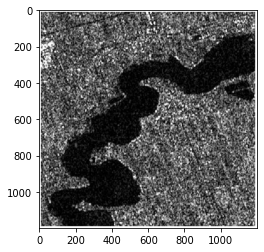

In [ ]:
plt.imshow(image_gray, cmap="gray")

# Точечная бинаризация

In [ ]:
import copy

bin_img = copy.deepcopy(image_gray)
T  = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

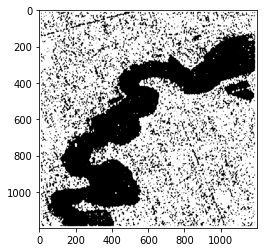

In [ ]:
plt.imshow(bin_img, cmap="gray")

# Бинаризация Отсу

In [ ]:
# otsu binarization
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

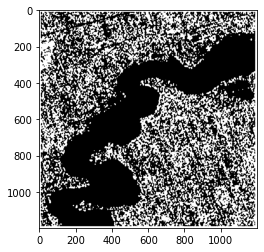

In [ ]:
plt.imshow(th2, cmap="gray")

# Адаптивная бинаризация

In [ ]:
#
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)


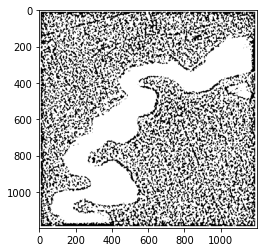

In [ ]:
plt.imshow(th3, cmap="gray")

# Оператор Собеля

In [ ]:
scale = 1
delta = 0
ddepth = cv2.CV_16S
grad_x = cv2.Sobel(image_gray, ddepth, 1, 0, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)
grad_y = cv2.Sobel(image_gray, ddepth, 0, 1, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)

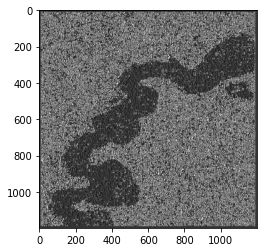

In [ ]:
plt.imshow((grad_x - grad_x.min())*255, cmap="gray")

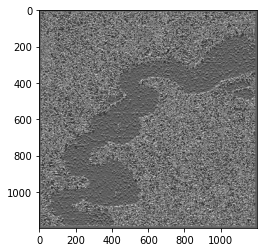

In [ ]:
plt.imshow((grad_y - grad_y.min())*255, cmap="gray")

In [ ]:
grad = cv2.addWeighted(grad_x, 0.5, grad_y, 0.5,0.0) # mean value between

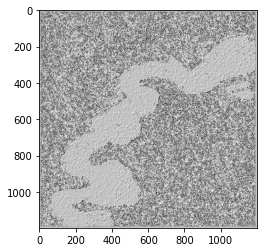

In [ ]:
plt.imshow((grad - grad.min())*255, cmap="gray")

# Canny

In [ ]:
edges = cv2.Canny(image_gray,100,200)

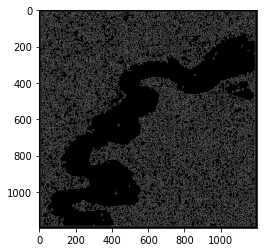

In [ ]:
plt.imshow(edges, cmap="gray")

# Преобразование Хафа

In [ ]:
image = cv2.imread('img_1.jpg')
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

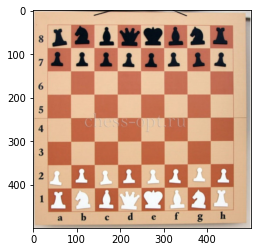

In [ ]:
plt.imshow(image)

In [ ]:
canny = cv2.Canny(image_gray,50,150,apertureSize = 3)

In [ ]:
lines = cv2.HoughLines(canny, 1, np.pi / 180, 190)

In [ ]:
import math

if lines is not None:
        for i in range(0, len(lines)):
            rho = lines[i][0][0]
            theta = lines[i][0][1]
            a = math.cos(theta)
            b = math.sin(theta)
            x0 = a * rho
            y0 = b * rho
            pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
            pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
            cv2.line(image, pt1, pt2, (0,0,255), 3, cv2.LINE_AA)

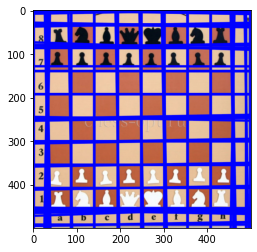

In [ ]:
plt.imshow(image)

In [ ]:
#ДЗ
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

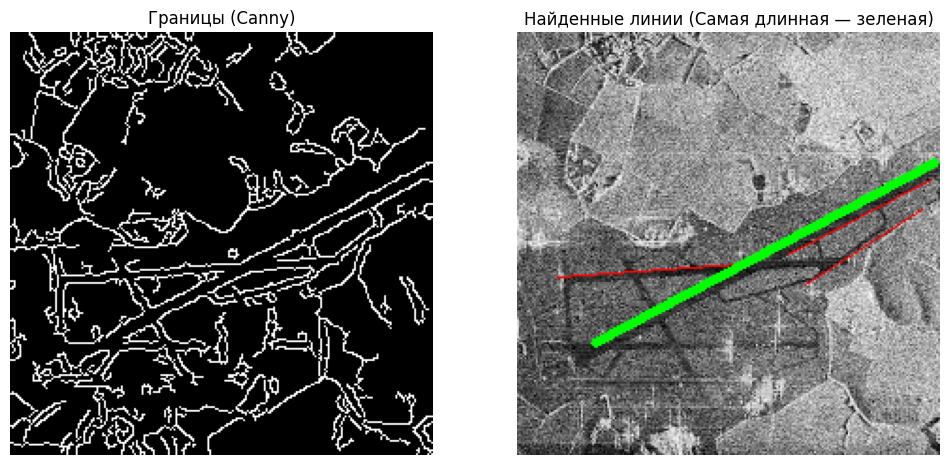

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/content/sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(image_gray, (5, 5), 1.5)

edges = cv2.Canny(blurred, 50, 150, apertureSize=3)

lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=80,
                        minLineLength=50, maxLineGap=10)

max_len = 0
best_line = None

line_image = image.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

        cv2.line(line_image, (x1, y1), (x2, y2), (0, 0, 255), 1)

        if length > max_len:
            max_len = length
            best_line = (x1, y1, x2, y2)

if best_line is not None:
    x1, y1, x2, y2 = best_line
    cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Границы (Canny)")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Найденные линии (Самая длинная — зеленая)")
plt.imshow(cv2.cvtColor(line_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

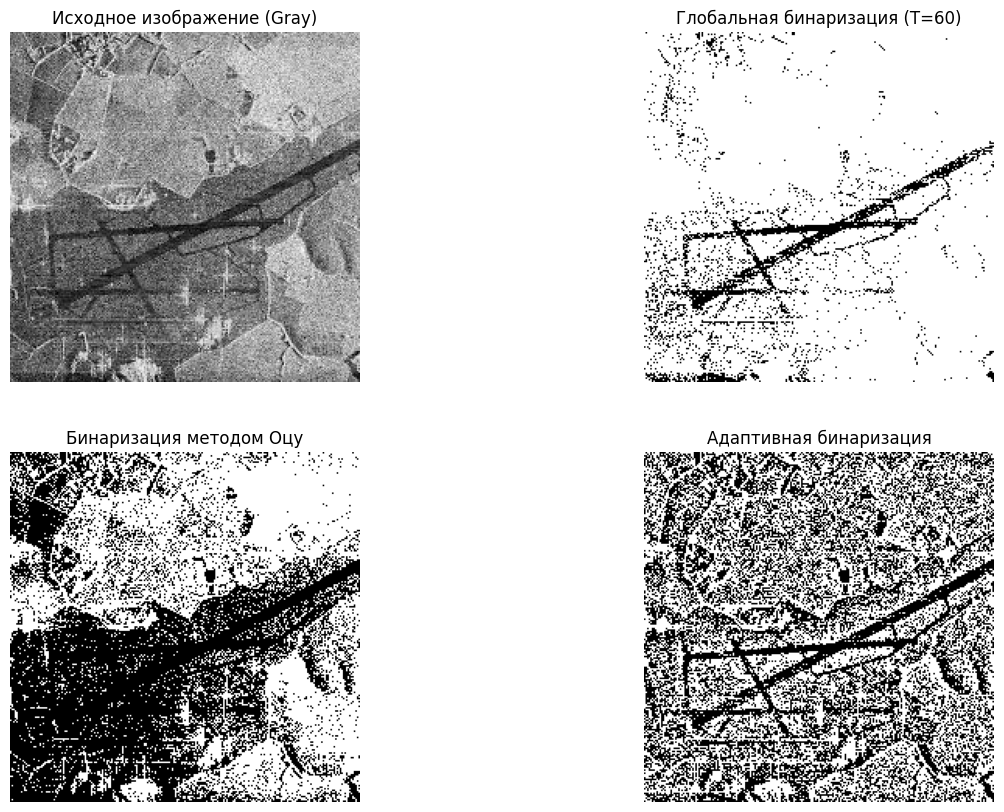

In [2]:
_, thresh_global = cv2.threshold(image_gray, 60, 255, cv2.THRESH_BINARY)

_, thresh_otsu = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

thresh_adaptive = cv2.adaptiveThreshold(
    image_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=31,
    C=5
)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.title("Исходное изображение (Gray)")
plt.imshow(image_gray, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Глобальная бинаризация (T=60)")
plt.imshow(thresh_global, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Бинаризация методом Оцу")
plt.imshow(thresh_otsu, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Адаптивная бинаризация")
plt.imshow(thresh_adaptive, cmap='gray')
plt.axis('off')

plt.show()